# LTAT.05.025 – Business Process Mining
## Task 3: SLA Compliance Analysis
**Owner:** Hashim Ali

**SLA Thresholds (full cycle time):**
- Labels: **15 weeks**
- Products for Resale: **13 weeks**
- Containers & Lids < 30L (plastic & metal): **16 weeks**
- All others: **11 weeks**

> **Note:** Only **completed** cases are used for SLA analysis. Ongoing cases have no final end time so their cycle time is incomplete and would underestimate violations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
from IPython.display import display

pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
print('Ready.')

Ready.


In [ ]:
# ── LOAD SHARED CSV (from Task 1) ─────────────────────────────────────────────
FILE = 'coatxr_cases_shared.csv'  # update path if needed

df = pd.read_csv(FILE, parse_dates=['start_time', 'end_time'])
print(f'Total cases: {len(df):,}')
print(f'Completed  : {(df["Status"]=="Completed").sum():,}')
print(f'Ongoing    : {(df["Status"]=="Ongoing").sum():,}')

Total cases: 59,385
Completed  : 46,229
Ongoing    : 13,156


In [ ]:
# ── FILTER: COMPLETED CASES ONLY ─────────────────────────────────────────────
completed = df[df['Status'] == 'Completed'].copy()
# Also exclude Consignment — different process, no invoices
completed = completed[completed['Item Type'] != 'Consignment']
print(f'Completed non-consignment cases for SLA analysis: {len(completed):,}')

Completed non-consignment cases for SLA analysis: 43,381


In [ ]:
# ── DEFINE SLA THRESHOLDS ─────────────────────────────────────────────────────
# Convert weeks to days (1 week = 7 days)
SLA_WEEKS = {
    'Labels':                           15,
    'Products for Resale':              13,
    'Plastic Containers & Lids < 30L':  16,
    'Metal Containers & Lids < 30L':    16,
    # All others → 11 weeks
}
DEFAULT_SLA_WEEKS = 11

def get_sla_days(spend_area):
    weeks = SLA_WEEKS.get(spend_area, DEFAULT_SLA_WEEKS)
    return weeks * 7

completed['sla_days']     = completed['Sub spend area text'].apply(get_sla_days)
completed['sla_weeks']    = completed['sla_days'] / 7
completed['cycle_weeks']  = completed['cycle_time_days'] / 7
completed['sla_violated'] = completed['cycle_time_days'] > completed['sla_days']
completed['days_over']    = (completed['cycle_time_days'] - completed['sla_days']).clip(lower=0)

print('SLA thresholds applied:')
for area in completed['Sub spend area text'].unique():
    days = get_sla_days(area)
    print(f'  {area:<40} {days/7:.0f} weeks ({days} days)')

SLA thresholds applied:
  Labels                                   15 weeks (105 days)
  Plastic Containers & Lids < 30L          16 weeks (112 days)
  Metal Containers & Lids < 30L            16 weeks (112 days)
  Products for Resale                      13 weeks (91 days)
  Trading products (old structure)         11 weeks (77 days)
  Packaging                                11 weeks (77 days)
  nan                                      11 weeks (77 days)
  Technical Services                       11 weeks (77 days)
  Packaging - Other                        11 weeks (77 days)


## 3.1 – Overall SLA Compliance

=== OVERALL SLA COMPLIANCE ===
Total completed cases : 43,381
SLA Met               : 23,123 (53.3%)
SLA Violated          : 20,258 (46.7%)


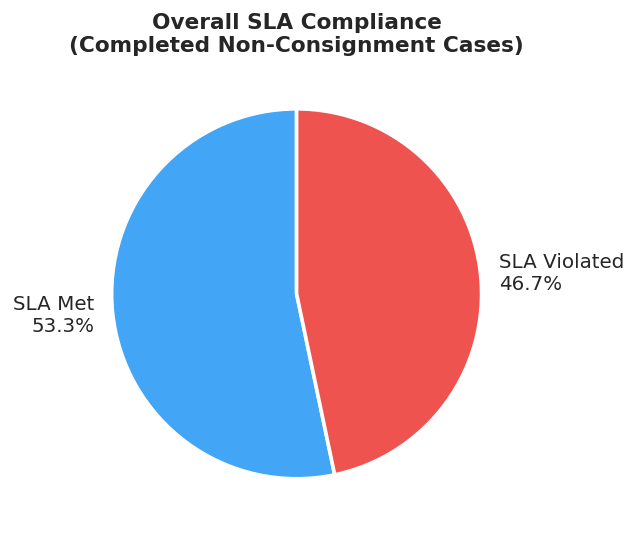

In [ ]:
# ── OVERALL COMPLIANCE ────────────────────────────────────────────────────────
total = len(completed)
violated = completed['sla_violated'].sum()
compliant = total - violated

print('=== OVERALL SLA COMPLIANCE ===')
print(f'Total completed cases : {total:,}')
print(f'SLA Met               : {compliant:,} ({compliant/total*100:.1f}%)')
print(f'SLA Violated          : {violated:,} ({violated/total*100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [compliant, violated],
    labels=[f'SLA Met\n{compliant/total*100:.1f}%', f'SLA Violated\n{violated/total*100:.1f}%'],
    colors=['#42A5F5', '#EF5350'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Overall SLA Compliance\n(Completed Non-Consignment Cases)', fontweight='bold')
plt.tight_layout()
plt.savefig('task3_overall_compliance.png', bbox_inches='tight')
plt.show()

## 3.2 – SLA Violations per Spend Area

In [ ]:
# ── VIOLATIONS PER SPEND AREA ─────────────────────────────────────────────────
sla_summary = completed.groupby('Sub spend area text').agg(
    Total_Cases=('sla_violated', 'count'),
    Violations=('sla_violated', 'sum'),
    SLA_Weeks=('sla_weeks', 'first'),
    Median_Cycle_Weeks=('cycle_weeks', 'median'),
    Mean_Cycle_Weeks=('cycle_weeks', 'mean'),
    Max_Cycle_Weeks=('cycle_weeks', 'max'),
    Avg_Days_Over=('days_over', 'mean')
).reset_index()

sla_summary['Violation_Rate_%'] = (sla_summary['Violations'] / sla_summary['Total_Cases'] * 100).round(1)
sla_summary = sla_summary.sort_values('Violation_Rate_%', ascending=False)

print('=== SLA VIOLATIONS PER SPEND AREA ===')
display(sla_summary[[
    'Sub spend area text', 'SLA_Weeks', 'Total_Cases', 'Violations',
    'Violation_Rate_%', 'Median_Cycle_Weeks', 'Mean_Cycle_Weeks', 'Avg_Days_Over'
]].round(2))

=== SLA VIOLATIONS PER SPEND AREA ===


,Sub spend area text,SLA_Weeks,Total_Cases,Violations,Violation_Rate_%,Median_Cycle_Weeks,Mean_Cycle_Weeks,Avg_Days_Over
3,Packaging - Other,11.00,882,789,89.50,16.33,15.13,34.62
0,Labels,15.00,24349,18085,74.30,16.41,16.07,12.52
2,Packaging,11.00,54,40,74.10,14.23,13.46,25.13
6,Technical Services,11.00,19,6,31.60,2.29,6.63,11.71
7,Trading products (old structure),11.00,2686,294,10.90,8.39,9.14,5.33
5,Products for Resale,13.00,5855,639,10.90,8.44,9.08,3.88
1,Metal Containers & Lids < 30L,16.00,4180,303,7.20,11.47,11.10,0.89
4,Plastic Containers & Lids < 30L,16.00,5299,68,1.30,11.19,11.41,0.18


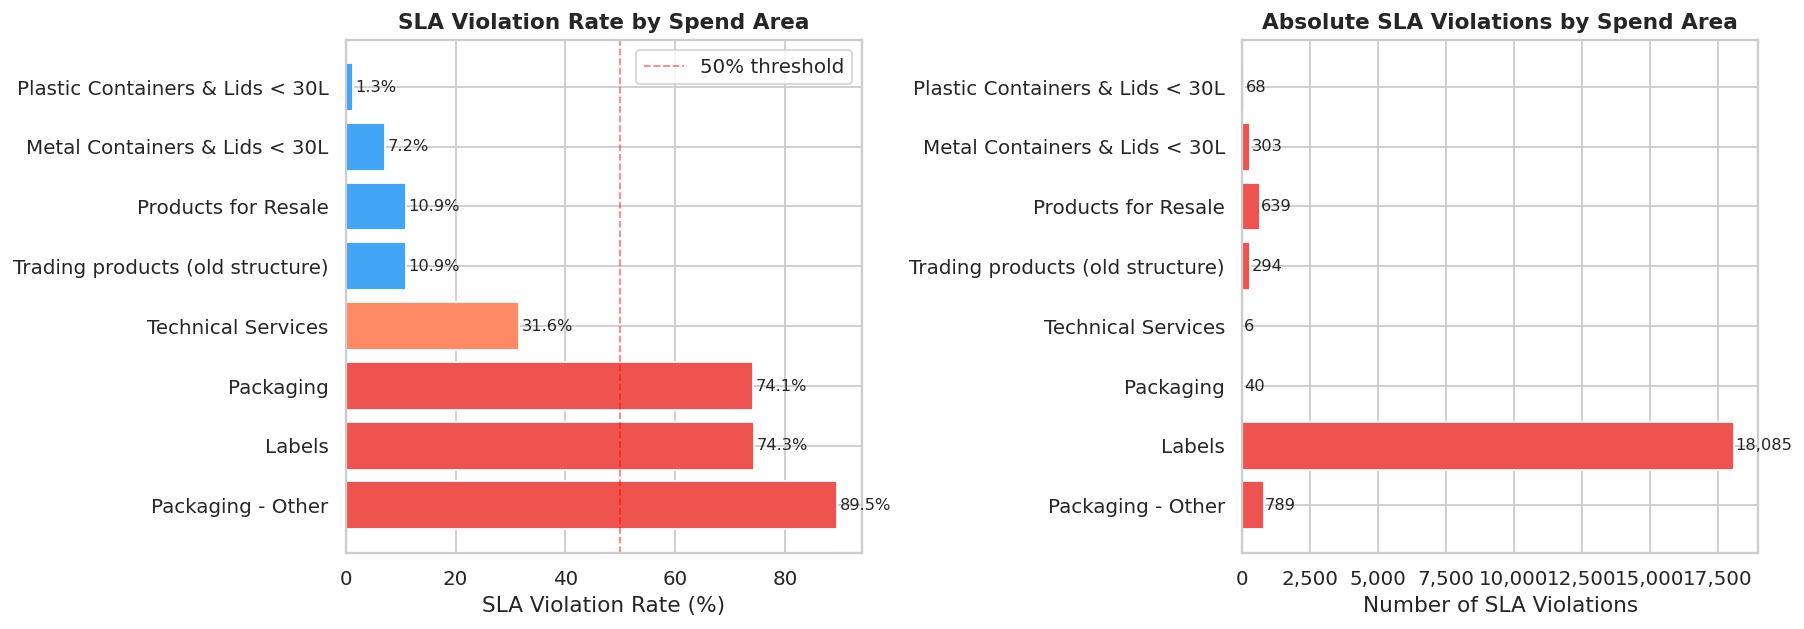

In [ ]:
# ── VIOLATION RATE BAR CHART ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: violation rate %
colors = ['#EF5350' if v > 50 else '#FF8A65' if v > 25 else '#42A5F5'
          for v in sla_summary['Violation_Rate_%']]
bars = axes[0].barh(sla_summary['Sub spend area text'], sla_summary['Violation_Rate_%'], color=colors)
axes[0].set_xlabel('SLA Violation Rate (%)')
axes[0].set_title('SLA Violation Rate by Spend Area', fontweight='bold')
axes[0].axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% threshold')
for bar, val in zip(bars, sla_summary['Violation_Rate_%']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[0].legend()

# Right: absolute violation counts
axes[1].barh(sla_summary['Sub spend area text'], sla_summary['Violations'], color='#EF5350')
axes[1].set_xlabel('Number of SLA Violations')
axes[1].set_title('Absolute SLA Violations by Spend Area', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(axes[1].patches, sla_summary['Violations']):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{int(val):,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('task3_violations_by_spend_area.png', bbox_inches='tight')
plt.show()

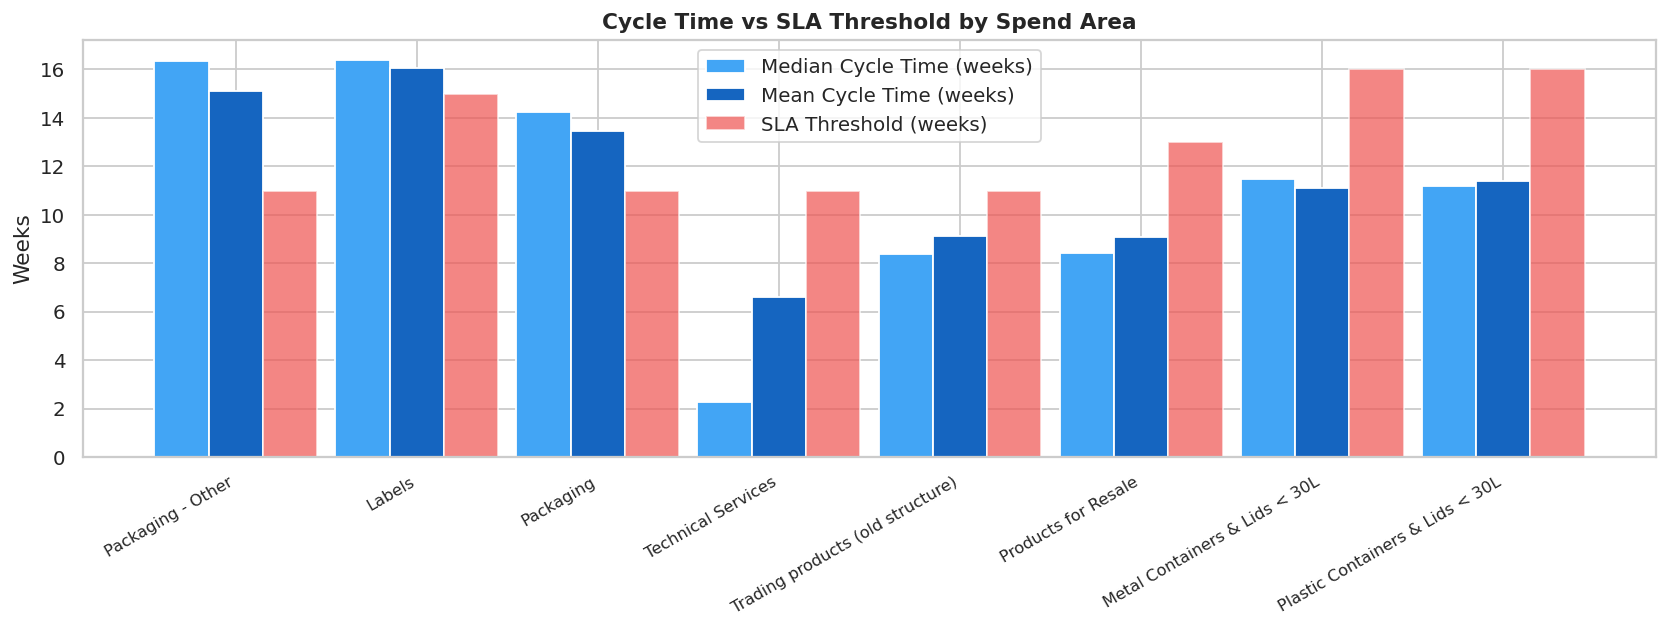

In [ ]:
# ── CYCLE TIME vs SLA THRESHOLD PER SPEND AREA ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

spend_areas = sla_summary['Sub spend area text'].tolist()
x = np.arange(len(spend_areas))
width = 0.3

ax.bar(x - width, sla_summary['Median_Cycle_Weeks'], width, label='Median Cycle Time (weeks)', color='#42A5F5')
ax.bar(x, sla_summary['Mean_Cycle_Weeks'], width, label='Mean Cycle Time (weeks)', color='#1565C0')
ax.bar(x + width, sla_summary['SLA_Weeks'], width, label='SLA Threshold (weeks)', color='#EF5350', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(spend_areas, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Weeks')
ax.set_title('Cycle Time vs SLA Threshold by Spend Area', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('task3_cycletime_vs_sla.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_518/4038366811.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)


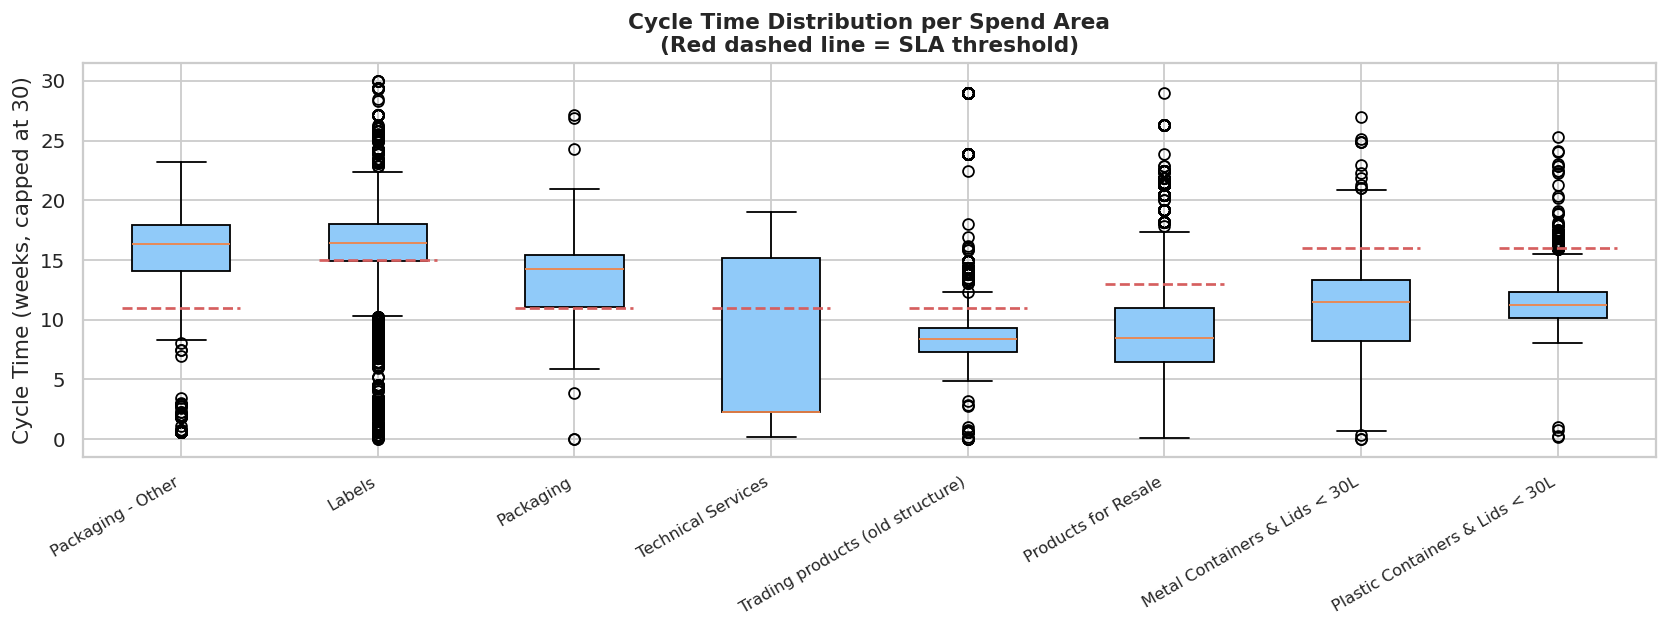

In [ ]:
# ── CYCLE TIME DISTRIBUTION PER SPEND AREA (boxplot) ─────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

order = sla_summary['Sub spend area text'].tolist()
data = [completed[completed['Sub spend area text'] == s]['cycle_weeks'].clip(upper=30).values for s in order]
sla_lines = [sla_summary[sla_summary['Sub spend area text'] == s]['SLA_Weeks'].values[0] for s in order]

bp = ax.boxplot(data, labels=order, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#90CAF9')

# Draw SLA threshold line per group
for i, sla in enumerate(sla_lines):
    ax.plot([i + 0.7, i + 1.3], [sla, sla], 'r--', linewidth=1.5)

ax.set_xticklabels(order, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Cycle Time (weeks, capped at 30)')
ax.set_title('Cycle Time Distribution per Spend Area\n(Red dashed line = SLA threshold)', fontweight='bold')
plt.tight_layout()
plt.savefig('task3_boxplot_sla.png', bbox_inches='tight')
plt.show()

## 3.3 – Worst Violating Cases

In [ ]:
# ── TOP 10 WORST VIOLATIONS ───────────────────────────────────────────────────
worst = completed[completed['sla_violated']].nlargest(10, 'days_over')[[
    'Case Identifier', 'Sub spend area text', 'Vendor',
    'cycle_weeks', 'sla_weeks', 'days_over'
]].copy()
worst['weeks_over'] = (worst['days_over'] / 7).round(1)
worst['cycle_weeks'] = worst['cycle_weeks'].round(1)

print('Top 10 worst SLA violations (by days over threshold):')
display(worst)

Top 10 worst SLA violations (by days over threshold):


,Case Identifier,Sub spend area text,Vendor,cycle_weeks,sla_weeks,days_over,weeks_over
16290,4507021966_00120,Labels,vendorID_0120,35.30,15.00,141.98,20.30
19142,4507024785_00170,Labels,vendorID_0136,33.40,15.00,129.10,18.40
19158,4507024785_00340,Labels,vendorID_0136,33.40,15.00,129.10,18.40
19165,4507024785_00410,Labels,vendorID_0136,33.40,15.00,129.10,18.40
15519,4507021136_00020,Trading products (old structure),vendorID_0118,29.00,11.00,126.08,18.00
15520,4507021136_00040,Trading products (old structure),vendorID_0118,29.00,11.00,126.08,18.00
15521,4507021136_00050,Trading products (old structure),vendorID_0118,29.00,11.00,126.08,18.00
15522,4507021136_00060,Trading products (old structure),vendorID_0118,29.00,11.00,126.08,18.00
15523,4507021136_00070,Trading products (old structure),vendorID_0118,29.00,11.00,126.08,18.00
15524,4507021136_00080,Trading products (old structure),vendorID_0118,29.00,11.00,126.08,18.00


## 3.4 – Summary

In [ ]:
# ── FINAL SUMMARY ─────────────────────────────────────────────────────────────
print('=== TASK 3 SUMMARY ===')
print(f'Completed cases analysed : {total:,}')
print(f'Overall violation rate   : {violated/total*100:.1f}%')
print(f'Overall violations       : {violated:,} cases')
print()
print('Per spend area:')
for _, row in sla_summary.iterrows():
    flag = '❌' if row['Violation_Rate_%'] > 50 else '⚠️' if row['Violation_Rate_%'] > 20 else '✅'
    print(f"  {flag} {row['Sub spend area text']:<42} "
          f"SLA={row['SLA_Weeks']:.0f}wks | "
          f"Violations={int(row['Violations']):,} ({row['Violation_Rate_%']}%) | "
          f"Median={row['Median_Cycle_Weeks']:.1f}wks")

=== TASK 3 SUMMARY ===
Completed cases analysed : 43,381
Overall violation rate   : 46.7%
Overall violations       : 20,258 cases

Per spend area:
  ❌ Packaging - Other                          SLA=11wks | Violations=789 (89.5%) | Median=16.3wks
  ❌ Labels                                     SLA=15wks | Violations=18,085 (74.3%) | Median=16.4wks
  ❌ Packaging                                  SLA=11wks | Violations=40 (74.1%) | Median=14.2wks
  ⚠️ Technical Services                         SLA=11wks | Violations=6 (31.6%) | Median=2.3wks
  ✅ Trading products (old structure)           SLA=11wks | Violations=294 (10.9%) | Median=8.4wks
  ✅ Products for Resale                        SLA=13wks | Violations=639 (10.9%) | Median=8.4wks
  ✅ Metal Containers & Lids < 30L              SLA=16wks | Violations=303 (7.2%) | Median=11.5wks
  ✅ Plastic Containers & Lids < 30L            SLA=16wks | Violations=68 (1.3%) | Median=11.2wks
